# Visualisierung mit R

### Dietmar Hareter und Fabian Pribahsnik
### 29.04.2026

***

In diesem Vortrag werden schwerpunktmäßig die Grundlagen der statischen Grafiken mit *ggplot* vorgestellt, gleichzeitig aber auch interaktive Grafiken mit plotly behandeln.

Zu Beginn werden die benötigten Pakete geladen.

In [ ]:
suppressPackageStartupMessages({
  # Visualisierung
  library(ggplot2)        # Standardpaket zur Erstellung statischer Grafiken basierend auf der "Grammar of Graphics"
  library(plotly)         # Ermöglicht interaktive Plots und bietet die Möglichkeit, ggplot2-Grafiken in interaktive Grafiken zu konvertieren.

  # Datenmanipulation
  library(dplyr)          # Zentrale Funktionen zur Datenmanipulation (filtern, gruppieren, zusammenfassen etc.)
  #library(plyr)           # Enthält Funktionen für das Teilen, Bearbeiten und Zusammenfügen von Datensätzen
  library(stringr)        # Einheitliche und einfache Funktionen zur Bearbeitung von Strings
  library(tibble)         # Moderne Variante von data.frames mit verbesserter Darstellung
  library(tidyr)          # Funktionen zum Umformen von Daten (z.B. pivotieren, long/wide-Format)
  library(forcats)        # Speziell entwickelt für den Umgang mit kategorialen Daten (Factors)
    
  # Generelle Pakete
  library(datasets)       # Enthält eine große Anzahl von Beispiel-Datensätzen zu Übungszwecken
})

In [ ]:
options(repr.plot.width = 8, repr.plot.height = 8) # Anpassung der Größe der im Folgenden erzeugten Plots
options(tibble.print_max = 10, tibble.print_min = 5)
options(repr.matrix.max.rows = 5, repr.matrix.max.cols = 15)

Zum Einstieg wird anhand eines kleinen Beispiels gezeigt, warum eine grafische Darstellung von Daten wichtig und hilfreich ist. Das Beispiel verwendet das sogenannte *Anscombe-Quartett*. Es besteht aus vier Mengen von Datenpunkten, die nahezu identische einfache statistische Eigenschaften, aber sehr unterschiedliche Muster haben. Der Datensatz wurde im Jahr 1973 von dem englischen Statistiker Francis Anscombe konstruiert, um die Bedeutung einer grafischen Datenanalyse hervorzuheben und die Effekte von Ausreißern zu demonstrieren.

Der Datensatz ist standardmäßig in *R* enthalten und kann einfach durch Eingabe von `anscombe` angezeigt werden.

In [ ]:
anscombe

Aus der Tabelle ist ersichtlich, dass alle Informationen (x- und y-Koordinaten) spaltenweise nebeneinander zur Verfügung stehen. Diese Darstellung ist aus dem 2. Seminarteil bekannt und wird `wide`-Format genannt. 

In einem Plot werden jeweils Informationen aus einer Spalte für eine „Informationsquelle“ herangezogen, beispielsweise Werte für die x-Achse, y-Achse, Farbe usw. Damit die Daten für statistische Methoden und grafische Auswertungen leichter verwendet werden können, wird der Datensatz zunächst in eine geeignete Form gebracht. Wünschenswert ist eine Form, in der alle x-Werte und y-Werte jeweils in einer Spalte stehen und eine zusätzliche Spalte die Information über die Zugehörigkeit enthält.

In [ ]:
Datensatz_1 <- data.frame(x = anscombe$x1, y = anscombe$y1, Datensatz = "Datensatz 1")
Datensatz_2 <- data.frame(x = anscombe$x2, y = anscombe$y2, Datensatz = "Datensatz 2")
Datensatz_3 <- data.frame(x = anscombe$x3, y = anscombe$y3, Datensatz = "Datensatz 3")
Datensatz_4 <- data.frame(x = anscombe$x4, y = anscombe$y4, Datensatz = "Datensatz 4")

data_anscombe <- rbind(Datensatz_1, Datensatz_2, Datensatz_3, Datensatz_4) # rbind (=rowbind)

In [ ]:
head(x = data_anscombe, n = 12) # Zeigt die ersten 12 Daten eines Datensatz an (die 2. Nummer ist optional und ist standardmäßig 6)

Aus der Tabelle ist ersichtlich, dass nach der Transformation der Daten die einzelnen x- und y-Werte für alle 4 Datensätze untereinander stehen. Die einzelnen Datensätze wurden durch die Funktion `rbind()` zeilenweise zusammengefügt (`long`-Format).

**Bemerkung**: Mit den in Seminar-Teil 2 vorgestellten Funktionen aus tidyverse wäre eine Möglichkeit der Umformung ...

In [ ]:
data_anscombe_test <- anscombe %>%
  tidyr::pivot_longer(
    cols = dplyr::everything(),
    names_to = c(".value", "Datensatz"),
    names_pattern = "([xy])(\\d)"
  ) %>%
  dplyr::select(x, y, Datensatz) %>%
  dplyr::mutate(Datensatz = paste0("Datensatz ", Datensatz)) %>%
  dplyr::arrange(Datensatz)

head(data_anscombe_test, 12)

Die obige Formel für die Umformung in das Long-Format wurde von ChatGPT geschrieben:

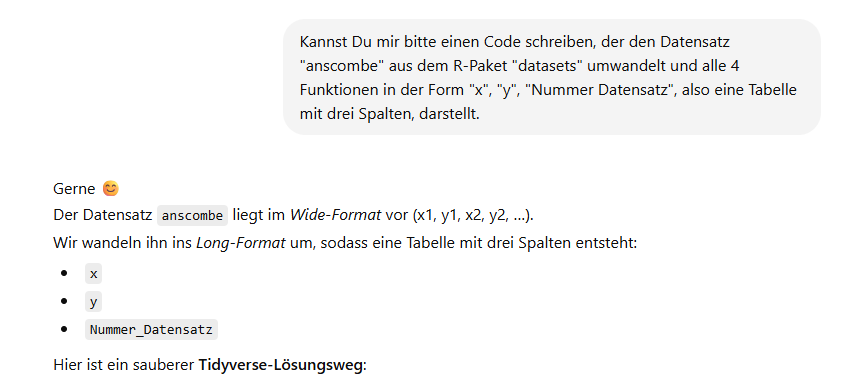

Im Folgenden wird der Mittelwert der x- und y-Werte der 4 Datensätze berechnet. 

In [ ]:
aggregate(cbind(x, y) ~ Datensatz, data = data_anscombe, FUN = mean)

Alle vier Datensätze haben sowohl für die x-Werte, als auch für die y-Werte annähernd denselben Mittelwert.

In [ ]:
aggregate(cbind(x, y) ~ Datensatz, data_anscombe, sd)

Alle vier Datensätze haben sowohl für die x-Werte, als auch für die y-Werte annähernd dieselbe Standardabweichung.

In [ ]:
Korrelation <- function(data) {                     # Definiere die Funktion "Korrelation"
  x <- data.frame(r = round(cor(data$x, data$y),3)) # Berechne die Korrelation auf 3 Nachkommastellen genau und stelle das Ergebnis als data.frame dar
  return(x)                                         # Ergebnis wird zurückgegeben
}

plyr::ddply(.data = data_anscombe, .variables = "Datensatz", .fun = Korrelation)

Alle vier Datensätze haben annähernd dieselbe Korrelation.

**Hinweis:** Die Funktion `ddply` teilt einen Datensatz (.data) nach einer Variable (.variables), führt für jeden Teilbestand eine Funktion (.fun) aus und stellt die Ergebnisse wieder zu einem Datensatz zusammen.

In [ ]:
Lin_Reg <- function(data) {                    # Definiere die Funktion "Lin_Reg"
  Dummy <- lm(y ~ x, data)                     # Wende ein lineares Modell (=lm) auf die Daten an
  Parameter <- round(t(Dummy$coefficients),2)  # Runde die Parameter des lin. Modells auf 2 Nachkommastellen
  x <- data.frame(Parameter)                   # Speicher die Parameter in einem data.frame
  return(x)
}

plyr::ddply(.data = data_anscombe, .variables = "Datensatz", .fun = Lin_Reg)

Alle vier Datensätze haben dieselbe Regressionsgerade, d. h. alle vier Geraden schneiden die y-Achse beim Wert 3 und besitzen eine Steigung von 0.5.

Zur Veranschaulichung werden die 4 Datensätze mit den dazugehörenden Regressionsgeraden mit Hilfe des Pakets `ggplot2` geplottet. Die hier verwendete Syntax (Befehle) wird im weiteren Verlauf noch genauer erklärt. Das Beispiel zeigt, mit wie wenigen Codezeilen aussagekräftige Grafiken erzeugt werden können.

In [ ]:
ggplot(data = data_anscombe, aes(x = x, y = y)) +                                # Definiere Rohdaten für Plot
  geom_point(color = "black") +                                                  # Daten als schwarze Punkte zeichnen
  facet_wrap(. ~ Datensatz) +                                                    # Plotfenster pro Datensatz
  geom_smooth(formula = y ~ x, method = "lm", se = FALSE, data = data_anscombe)  # Regressionsgeraden einzeichnen

Aus den Plots ist ersichtlich, dass Datensatz 3 einen Ausreißer in y-Richtung und Datensatz 4 einen Ausreißer in x-Richtung hat. Datensatz 2 hat einen quadratischen Zusammenhang. Alle Datensätze haben dieselben statistischen Merkmale, unterscheiden sich jedoch deutlich voneinander.

**Bemerkung**: Grundsätzlich wird bei der Erstellung von Grafiken mit Hilfe des Pakets `ggplot2` die Grafik als Variable abgespeichert. Dies hat den großen Vorteil, dass dieser Variablen neue Eigenschaften schrittweise zugewiesen werden können und so die Grafik Schritt für Schritt aufgebaut bzw. erweitert werden kann.

Im Folgenden wird dieses Vorgehen angewandt, um die bereits oben dargestellte Grafik mit den Regressionsgeraden schrittweise aufzubauen. Dazu wird die Variable `MyPlot` schrittweise erweitert. Soll die Grafik geplottet (angezeigt) werden, so ist das einfach durch einen Aufruf des Variablennamens möglich.

In [ ]:
MyPlot <- ggplot(data = data_anscombe, aes(x = x, y = y)) # Definiere Rohdaten für Plot
MyPlot

Die einzelnen Datensätze werden erst nach der Angabe einer sogenannten „Geometrie“ (entspricht der Form der Darstellung – siehe später) angezeigt.

In [ ]:
MyPlot <- MyPlot + geom_point(color = "black")                 # Daten als schwarze Punkte zeichnen
MyPlot

In der einfachsten Form des Plots werden wie hier dargestellt alle Datenpunkte in eine Grafik eingezeichnet und können daher nicht unterschieden werden.

Im nächsten Schritt werden die einzelnen Datensätze in unterschiedlichen Plots dargestellt. Die Trennung erfolgt durch den Zusatz von `facet_wrap()`.

In [ ]:
MyPlot <- MyPlot + facet_wrap(. ~ Datensatz)  # Pro Datensatz ein eigenes Plotfenster verwenden
MyPlot

Im letzten Schritt wird eine lineare Regression hinzugefügt.

In [ ]:
MyPlot <- MyPlot + geom_smooth(formula = y ~ x, method = "lm", se = TRUE, data = data_anscombe) # Regressionsgeraden
MyPlot

## Die Pakete *ggplot2* und *plotly*

Das Paket `ggplot2` wurde von Hadley Wickham entwickelt und setzt die Idee der **Grammar of Graphics** um. Grafiken werden dabei aus **Layern** aufgebaut und über **Aesthetic Mappings** beschrieben. `gg` steht für `Grammar of Graphics` (siehe das Buch von Leland Wilkinson in der Literaturempfehlung).

Die einzelnen Elemente einer Grafik mit `ggplot` sind:

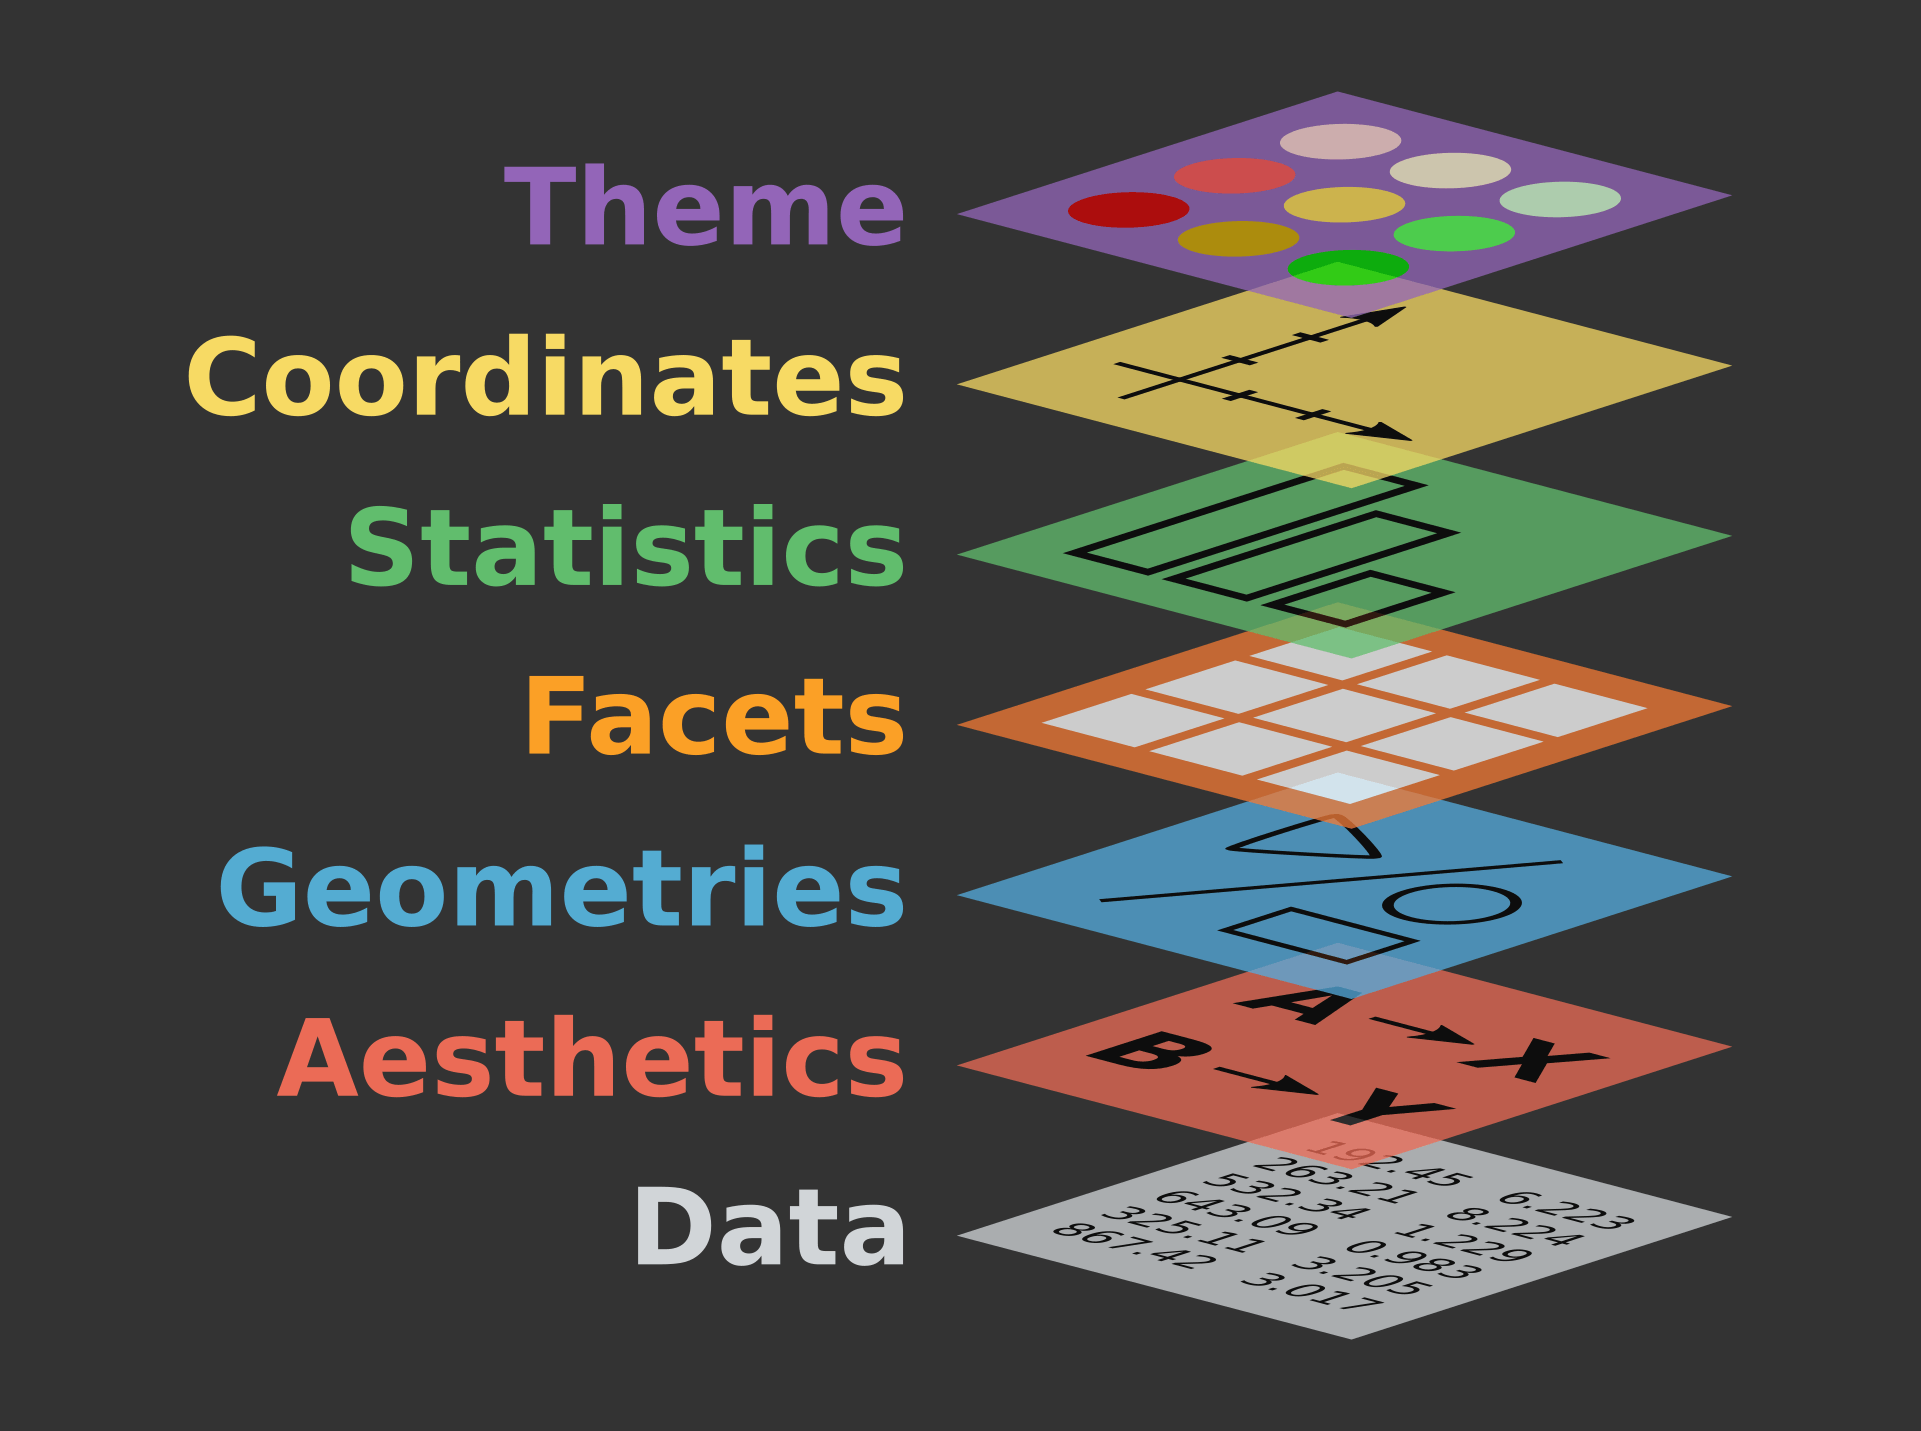

Die `Grammar of Graphics` beschreibt Visualisierung als Kombination mehrerer Bausteine:

- **Daten**: Was soll visualisiert werden?
- **Ästhetiken** (`aes()`): Welche Variablen werden auf der x-Achse, y-Achse, Farbe, Größe, Form usw. abgebildet?
- **Geometrien** (`geom_*`): Wie werden die Daten dargestellt? Punkte, Linien, Balken, Boxplots etc.
- **Statistiken** (`stat_*` oder implizit in Geoms): Welche Transformation wird intern berechnet?
- **Skalen** (`scale_*`): Wie werden Datenwerte auf visuelle Eigenschaften übersetzt?
- **Koordinaten** (`coord_*`): Wie wird der Plot räumlich aufgespannt?
- **Facets** (`facet_*`): Wie werden Teilgrafiken nebeneinander angeordnet?
- **Themes** (`theme_*`): Wie wird das Erscheinungsbild gestaltet?

Die wichtigste Grundidee in `ggplot2` wurde bereits oben dargestellt: ein Plot wird in einer Variable gespeichert und schrittweise **geschichtet**, d.h. jede neue Komponente wird mit `+` ergänzt.

### Vergleich zur Logik von plotly
`plotly` ist stärker objekt- und komponentenorientiert:

- Daten werden oft direkt in `plot_ly()` übergeben.
- Geometrien heißen dort meist **Trace Types** wie `scatter`, `bar`, `histogram`, `box`, `heatmap`.
- Layout, Achsen, Titel und Menüs werden separat über `layout()` gesteuert.
- Interaktivität ist standardmäßig eingebaut.

## Wichtige Unterschiede zwischen ggplot2 und plotly

### ggplot2
- hervorragend für **statische**, publikationsreife Abbildungen,
- sehr konsistente Grammatik,
- Themes und Feintuning sind stark ausgereift,
- besonders gut für Reports, Paper und reproduzierbare Dokumente.

### plotly
- ideal für **interaktive Exploration**,
- unterstützt standardmäßig Hover, Zoom und Klickinteraktion,
- besonders geeignet für Dashboards, Web-Anwendungen und Lehrpräsentationen,
- verlangt oft explizitere Steuerung von Layout, Tooltips und Gruppierung.

### Worauf ist bei den Unterschieden besonders zu achten?
1. **Interaktivität ist nicht nur "Bonus", sondern verändert die Gestaltung.**
   - **Tooltips** (das sind kleine Informationsfenster, die erscheinen, wenn die Maus über einen Datenpunkt fährt - auch als **Hover Labels** bezeichnet) sollten bewusst definiert werden.
   - Zu viele Informationen direkt im Plot sind oft nicht nötig, wenn Hover genutzt wird.
2. **Syntaxunterschiede:**
   - ggplot2 arbeitet mit **Layern**.
   - plotly arbeitet mit **Traces** und `layout()`.
3. **Standarddarstellung ist unterschiedlich.**
   - Farben, Legenden und Gruppierungen verhalten sich nicht immer identisch.
4. **Statistische Schichten** wie Regressionslinien sind in ggplot2 oft einfacher.
   - In plotly müssen Hilfsdaten manchmal vorher explizit berechnet werden.
5. **Facettierung** (einzelnen Teilgrafiken) ist in ggplot2 sehr elegant.
   - In plotly werden dafür oft `subplot()` oder `ggplotly()` genutzt.

Wie oben dargestellt, verfolgt `ggplot` eine sehr konsistente Grammatik und ermöglicht ein umfangreiches Feintuning der Grafiken. Vor allem der Aufbau nach dem Schichtprinzip macht die Erstellung von Grafiken sehr einfach.

Das Paket `plotly` stellt mit der Funktion `ggplotly()` eine Möglichkeit bereit, `ggplot2`-Grafiken interaktiv darzustellen. Dabei gehen jedoch in komplexeren Fällen gelegentlich Formatierungsdetails verloren oder werden anders interpretiert.

In [ ]:
# Ursprünglicher Code
p <- ggplot(data = data_anscombe, aes(x = x, y = y)) +
  geom_point(color = "black") +
  facet_wrap(. ~ Datensatz) +
  geom_smooth(formula = y ~ x, method = "lm", se = FALSE)

# Umwandlung in einen interaktiven Plot
ggplotly(p, width = 800, height = 500)

Der folgende Schwerpunkt liegt auf den einzelnen Layern von ggplot. Wie oben dargestellt, sind die Möglichkeiten mit diesem Paket deutlich umfangreicher und der Aufbau der Grafik durch das Layer-System deutlich einfacher im Vergleich zu plotly. 

### 1. Daten

Für die nachfolgenden Darstellungen wird der bereits aus dem 2. Seminarteil bekannte Datensatz `mtcars` verwendet und entsprechend aufbereitet. Im Gegensatz zur Aufbereitung im 2. Seminarteil werden hier alle Integer-Variablen in Faktoren umgewandelt.

In [ ]:
mtcars2 <- mtcars %>%
  dplyr::mutate(
    vs = factor(vs, labels = c("V-shaped", "Straight")),
    am = factor(am, labels = c("Automatik", "Manuell")),
    cyl = factor(cyl),
    gear = factor(gear),
    carb = factor(carb)) 

colnames(mtcars2) <- c("Reichweite", "Anz_Zylinder", "Hubraum", "PS", "Hinterachse", "Gewicht", "Beschl.", 
                       "Motorart", "Getriebe", "Anz_Gänge", "Anz_Vergaser")
mtcars2 <- tibble::rownames_to_column(.data = mtcars2, var = "Modell")

head(mtcars2)

Die Änderungen sind auch in der Struktur ersichtlich.

In [ ]:
str(mtcars2)

**Hinweis:** Diskrete oder nichtnumerische Ausprägungen, die keine natürliche Ordnung haben, werden häufig über die Funktion `factor()` als *Faktoren* definiert. Die Ausprägungen können mit der Funktion `levels()` abgefragt werden, sind standardmäßig alphabetisch aufsteigend sortiert und werden in einem Plot in dieser Reihenfolge angezeigt.

In [ ]:
levels(mtcars2$Anz_Vergaser) # Verschiedene Faktorausprägungen

Diese standardmäßige alphabetische Sortierung kann mit Hilfe von geeigneten Funktionen einfach geändert werden - siehe später - bzw. eine Ordnung der Faktoren definiert werden:

In [ ]:
Werte <- factor(c("Klein", "Groß", "Durchschnitt", "Klein", "Durchschnitt"))
Werte
levels(Werte)
Werte[1] < Werte[2]

Die einzelnen Faktoren haben keine festgelegte Anordnung und können deshalb auch nicht größenmäßig verglichen werden - siehe die letzte Fehlermeldung. Mit Hilfe der Funktion `ordered()` kann eine entsprechende Anordnung vorgegeben werden:

In [ ]:
Werte <- ordered(Werte, levels = c("Klein", "Durchschnitt", "Groß"))
Werte
levels(Werte)
Werte[1] < Werte[2]

In [ ]:
# Speicher bereinigen um RAM Verbrauch zu reduzieren
rm(list = setdiff(ls(), c("mtcars2", "data_anscombe")))
# Garbage collection
gc()

### 2. Aesthetics und 3. Geometrie

Ein `ggplot`-Plot besteht in seiner Minimalform aus den drei Komponenten *Datensatz*, *Aesthetics* und *Geometrie* und hat den codetechnischen Aufbau

`ggplot(data = Datensatz, aes(x = Spaltenname_für_x-Werte, y = Spaltenname_für_y-Werte)) + geom_...()`

Aesthetics sind Zuordnungen von Variablen zu grafischen Eigenschaften des Plots sowie zusätzliche Angaben zur Darstellung.

Die Werte der x-Achse werden mit `x =` bzw. die Werte der y-Achse mit `y =` und dem Namen der entsprechenden Spalte im Datensatz angegeben.

Mögliche Zusatzinformationen (Auszug):
- `color`: Unterschiedliche Ausprägungen werden unterschiedlich eingefärbt.
- `size`: Unterschiedliche Ausprägungen werden in unterschiedlicher Größe dargestellt.
- `shape`: Unterschiedliche Ausprägungen werden in unterschiedlicher Form dargestellt.
- `linetype`: Unterschiedliche Ausprägungen werden in unterschiedlicher Linienform dargestellt.

In [ ]:
ggplot(data_anscombe, aes(x = x, y = y, color = Datensatz)) +  # Färbe Punkte anhand des Wertes in der Spalte Datensatz ein.
  geom_point()                                                 # die Geometrie wird anschließend behandelt

***

**Aufgabe 1:** Im obigen Plot werden die Datensätze anhand unterschiedlichen Farben unterschieden. Ändern Sie den Code, so dass jeder Datensatz durch ein anderes Symbol (Form) dargestellt wird.

***

Die obige Grafik wird in `plotly` auf folgende Weise definiert bzw. erstellt:

In [ ]:
plot_ly(
  data = data_anscombe,
  x = ~x,
  y = ~y,
  color = ~Datensatz,
  type = "scatter",
  mode = "markers",
  width = 700,  # Breite in Pixeln
  height = 500  # Höhe in Pixeln
)

Der Parameter `type` gibt den Grundtyp des Plots vor. In einem ggplot entspricht dieser Parameter der Geometrie, die im Folgenden dargestellt wird. Typische Werte sind:
- **scatter**: Punkte / Linien 
- **bar**: Balkendiagramm
- **histogram**: Histogramm
- **box**: Boxplot

Der Parameter `mode` gibt die Darstellungsart innerhalb des Typs "scatter" vor:
- **markers**: nur Punkte (entspricht geom_point())
- **lines**: nur Linien (entspricht geom_line())
- **lines+markers**: beides kombiniert

Eine andere Möglichkeit, den Plot interaktiv zu erzeugen, ist die Verwendung der bereits erwähnten Funktion `ggplotly()`. Zunächst wird die `ggplot`-Grafik in einer Variable gespeichert und danach umgewandelt.

In [ ]:
p <- ggplot(data_anscombe, aes(x = x, y = y, color = Datensatz)) +
  geom_point()

ggplotly(p, width = 700, height = 500)

Wie bereits erwähnt, werden bei der Umwandlung mit der Funktion `ggplotly()` standardmäßig alle im `ggplot` enthaltenen Aesthetics in den einzelnen Punkten angezeigt. Die Anzeige kann mit dem Parameter *tooltip* eingeschränkt oder neu definiert werden (siehe weiter unten).

In [ ]:
# Zeigt nur die x- und y-Werte im Tooltip an
ggplotly(p, width = 700, height = 500, tooltip = c("x", "y"))

Im Folgenden werden einige Geometrien von *ggplot* vorgestellt.

| Kategorie            | Geom               | Zweck / Beschreibung         | Typischer Anwendungsfall     | 
| -------------------- | ------------------ | ---------------------------- | ---------------------------- | 
| **Grundlagen**       | `geom_point()`     | Punkte darstellen            | Streudiagramm                | 
|                      | `geom_jitter()`    | Punkte mit Streuung          | Overplotting vermeiden       |
|                      | `geom_line()`      | Linien (nach x sortiert)     | Zeitreihen                   | 
|                      | `geom_path()`      | Linien (in Datenreihenfolge) | Pfad-/Bewegungsdaten         | 
|                      | `geom_area()`      | Fläche unter Kurve           | Kumulative Werte             | 
| **Text**             | `geom_text()`      | Textlabels                   | Beschriftungen               | 
|                      | `geom_label()`     | Labels mit Hintergrund       | Hervorhebung                 | 
| **Balken**           | `geom_bar()`       | Zählt automatisch Fälle      | Häufigkeiten                 | 
|                      | `geom_col()`       | Nutzt vorhandene Werte       | Aggregierte Daten            | 
| **Verteilungen**     | `geom_histogram()` | Histogramm                   | Verteilung numerischer Daten | 
|                      | `geom_density()`   | Dichtekurve                  | Glatte Verteilungen          | 
|                      | `geom_boxplot()`   | Boxplot                      | Vergleich von Gruppen        | 
|                      | `geom_violin()`    | Dichte + Boxplot             | Verteilungen vergleichen     |
| **Spezialfälle**     | `geom_segment()`   | Liniensegmente               | Pfeile/Verbindungen          | 

#### Punkte - *geom_point()* bzw. *geom_jitter()*

Die einfachste Form eines Plots ist, jeden Datensatz durch einen Punkt darzustellen:

In [ ]:
ggplot(mtcars2, aes(x = Anz_Zylinder, y = Anz_Gänge)) +
  geom_point(size = 3)

Der Plot enthält auf beiden Achsen diskrete Ausprägungen (Faktoren). Es ist nicht ersichtlich, wie viele Beobachtungen in den einzelnen Punkten enthalten sind. Die folgende Auswertung ermittelt die entsprechenden Häufigkeiten.

In [ ]:
table(mtcars2$Anz_Gänge, mtcars2$Anz_Zylinder)

Aus der obigen Tabelle ist ersichtlich, dass einige Kombinationen aus `Anz_Gänge` und `Anz_Zylinder` mehrfach vorkommen. Diese Information kann aus dem einfachen Punktdiagramm nicht direkt abgelesen werden.

Eine Idee zur besseren Darstellung diskreter Ausprägungen ist es, zufällige Störfaktoren zu den Werten der einzelnen Datensätze zu addieren, damit sie nicht genau übereinander liegen. Diese Störfaktoren werden automatisch in der Geometrie `geom_jitter()` erzeugt.

In [ ]:
ggplot(mtcars2, aes(x = Anz_Zylinder, y = Anz_Gänge)) +
  geom_jitter(size = 3, width = 0.1, height = 0.1)

Die Transparenz der einzelnen Datenpunkte wird mit dem Faktor `alpha` gesteuert

In [ ]:
ggplot(mtcars2, aes(x = Anz_Zylinder, y = Anz_Gänge)) +
  geom_jitter(size = 3, width = 0.1, height = 0.1, alpha = 0.2)

***

**Aufgabe 2:** Visualisieren Sie das Verhältnis von PS zu Reichweite und interpretieren Sie das Ergebnis.

Interpretation: 

***

#### Liniengrafik - *geom_line()*

In [ ]:
ggplot(mtcars2, aes(x = PS, y = Reichweite)) +
  geom_line()

Geometrien können kombiniert werden

In [ ]:
ggplot(mtcars2, aes(x = PS, y = Reichweite)) +
  geom_point() +
  geom_line()

Horizontale Linien können durch `geom_hline()` bzw. vertikale Linien durch `geom_vline()` hinzugefügt werden. Eine diagonale Linie kann mit `geom_abline()` hinzugefügt werden.

In [ ]:
ggplot(mtcars2, aes(x = PS, y = Reichweite)) +
  geom_point(size = 3) +
  geom_hline(yintercept = 25, color = "red") +                               # horizontale Linie einfügen
  geom_vline(xintercept = 200, color = "blue") +                             # vertikale Linie einfügen
  geom_abline(intercept = 35, slope = -0.1, color = "white", linewidth = 5)  # diagonale Linie einfügen

#### Text - *geom_text()*

Textinformationen zu den einzelnen Datensätzen werden mit `geom_text()` hinzugefügt: 

In [ ]:
ggplot(mtcars2, aes(x = PS, y = Reichweite)) +
  geom_point() +
  geom_text(aes(label = Modell))

Die Position des Textes kann durch die Argumente `hjust` bzw. `vjust` angepasst werden:

In [ ]:
ggplot(mtcars2, aes(x = PS, y = Reichweite)) +
  geom_point() +
  geom_text(aes(label = Modell, hjust = -0.1, vjust = -0.1))

**Hinweis:** Die Textausgabe kann in einfacher Weise gesteuert werden. Beispielsweise ist es sehr einfach, lediglich die "Ausreißer" zu benennen:

In [ ]:
ggplot(mtcars2, aes(x = PS, y = Reichweite)) +
  geom_point() +
  geom_text(aes(label = ifelse(Reichweite > 30, Modell, ''), hjust = -0.1, vjust = -0.1))

Die originale Grafik mit der Benennung aller Punkte ist sehr überladen. In einer interaktiven Grafik können Informationen über die einzelnen Modellpunkte im `tooltip` verpackt werden.

In [ ]:
p <- ggplot(mtcars2, aes(x = PS, y = Reichweite, text = paste("Modell", Modell,
                                                              "<br>Gewicht:", Gewicht, 
                                                              "<br>Reichweite:", Reichweite, 
                                                              "<br>Zylinder:", Anz_Zylinder))) +
  geom_point() 

ggplotly(p, width = 700, height = 500, tooltip = c("text"))

#### Balkengrafik - *geom_bar()*

Eine Balkengrafik benötigt nur die Angabe einer Ausprägung (x-Achse) und zeigt die Häufigkeit der entsprechenden Werte. Die Farbe der Balken kann mit dem Parameter `fill` festgelegt werden. 

In [ ]:
ggplot(mtcars2, aes(x = Getriebe)) +
  geom_bar(fill = "darkblue")

In [ ]:
plot_ly(mtcars2, 
        x = ~Getriebe, 
        type = "histogram")

Zur Unterscheidung einzelner Ausprägungen können Aesthetics verwendet werden:

In [ ]:
ggplot(mtcars2, aes(x = Getriebe, fill = Anz_Zylinder)) +
  geom_bar()

Die Form der Balken kann mit einfachen Zusatzangaben verändert werden, beispielsweise für die Anzeige der relativen Verhältnisse ...

In [ ]:
ggplot(mtcars2, aes(x = Getriebe, fill = Anz_Zylinder)) +
  geom_bar(position = "fill")

... oder die Darstellung der Balken nebeneinander:

In [ ]:
ggplot(mtcars2, aes(x = Getriebe, fill = Anz_Zylinder)) +
  geom_bar(position = "dodge")

***

**Aufgabe 3:** Erstellen Sie eine Balkengrafik, die zeigt, wie viele Fahrzeuge im Datensatz pro Anzahl Zylinder (`Anz_Zylinder`) vorhanden sind. Wie sind die Ausprägung `Anz_Gänge` in den einzelnen Balken verteilt?

***

### Histogramm - *geom_histogram()*

Ein Histogramm benötigt ebenfalls nur die Angabe einer Ausprägung (x-Achse) und zeigt die Häufigkeitsverteilung der entsprechenden Werte. Zur Darstellung ist die Einteilung der Daten in Klassen (engl. `bins`) erforderlich. Standardmäßig wird die Achse in 30 Klassen eingeteilt.

In [ ]:
ggplot(mtcars2, aes(x = PS)) +
  geom_histogram()

Die Breite der einzelnen Klassen / Abschnitte auf der x-Achse (Balkenbreite) kann mit dem Argument `binwidth` vorgegeben werden: 

In [ ]:
ggplot(mtcars2, aes(x = PS)) +
  geom_histogram(binwidth = 25)

Die Anzahl der Klassen kann mit dem Argument `bins` vorgegeben werden:

In [ ]:
ggplot(mtcars2, aes(x = PS)) +
  geom_histogram(bins = 10)

Auch hier ist eine zusätzliche Unterscheidung einzelner Ausprägungen möglich:

In [ ]:
ggplot(mtcars2, aes(x = PS, fill = Anz_Zylinder)) +
  geom_histogram(bins = 10)

***

**Aufgabe 4:** Erzeugen Sie ein Histogramm der Variable `Reichweite`. Probieren Sie mindestens zwei verschiedene Einstellungen für `binwidth` oder `bins` aus und beurteilen Sie, welche Darstellung die Verteilung besser erkennen lässt.

***

Ein Dichte-Histogramm wird durch die zusätzliche Angabe `aes(y = after_stat(density))` erzeugt:

In [ ]:
ggplot(mtcars2, aes(x = PS, fill = Anz_Zylinder)) +
  geom_histogram(bins = 10, aes(y = after_stat(density)))

#### Boxplot - *geom_boxplot()*

Ein Boxplot zeigt eine einfache Darstellung der Verteilung eines Merkmals. Alle Daten werden im Wesentlichen auf 5 Informationen zusammengefasst: Median, 25%- und 75%-Quartile und die Extremwerte auf beiden Seiten.

In [ ]:
ggplot(mtcars2, aes(x = Getriebe, y = Reichweite)) +
  geom_boxplot()

Die Koordinaten können durch die Funktion `coord_flip()` vertauscht werden:

In [ ]:
ggplot(mtcars2, aes(x = Getriebe, y = Reichweite)) +
  geom_boxplot() + 
  coord_flip()

#### Segmente - *geom_segment()*

Segmente können zur Darstellung von Veränderungen, beispielsweise Zu- oder Abnahme in einem Jahr, verwendet werden. 

***

**Aufgabe 5:** Erstellen Sie einen Boxplot der `Reichweite` getrennt nach `Anz_Zylinder`. Drehen Sie die Darstellung anschließend mit `coord_flip()` und vergleichen Sie, welche Variante besser lesbar ist.


***

In [ ]:
data_segments <- data.frame(
    Produkte = c("A", "B", "C", "D", "E"),
    Jahr_2024 = c(100, 50, 70, 80, 30),
    Jahr_2025 = c(110, 40, 50, 100, 50)
  ) %>%
  mutate(Anstieg = Jahr_2025 - Jahr_2024,        # mutate: erzeugt neue Spalten, die aus anderen Spalten berechnet werden. 
         Produkte = factor(Produkte))
data_segments

In [ ]:
ggplot(data_segments) +
  geom_segment(aes(x = Jahr_2024, xend = Jahr_2025, y = Produkte, yend = Produkte),
               arrow = arrow(length = grid::unit(2, "mm"), type = "closed"),
               color = ifelse(data_segments$Anstieg > 0, "darkgreen", "red")) +
  geom_text(aes(label = Jahr_2024, x = Jahr_2024, y = Produkte, vjust = -0.5)) +
  geom_text(aes(label = Jahr_2025, x = Jahr_2025, y = Produkte, vjust = -0.5)) +
  geom_text(aes(label = Anstieg, x = (Jahr_2024 + Jahr_2025)/2, y = Produkte, vjust = -0.5))


Die diskrete Ausprägung „Produkte“ ist als Faktor formatiert und standardmäßig alphabetisch aufsteigend geordnet. Die Anordnung kann mit der Funktion `fct_reorder()` aus dem Paket `forcats` geändert werden.

Im Folgenden werden die Produkte nach dem Wert des Jahres 2024 sortiert.

In [ ]:
data_segments <- data_segments %>%
  mutate(Produkte = fct_reorder(Produkte, Jahr_2024))     # Die Faktoren von "Produkte" werden nach den Werten von 2024 sortiert.


In [ ]:
ggplot(data_segments) +
  geom_segment(aes(x = Jahr_2024, xend = Jahr_2025, y = Produkte, yend = Produkte),
               arrow = arrow(length = grid::unit(2, "mm"), type = "closed"),
               color = ifelse(data_segments$Anstieg > 0, "darkgreen", "red")) +
  geom_text(aes(label = Jahr_2024, x = Jahr_2024, y = Produkte, vjust = -0.5)) +
  geom_text(aes(label = Jahr_2025, x = Jahr_2025, y = Produkte, vjust = -0.5)) +
  geom_text(aes(label = Anstieg, x = (Jahr_2024 + Jahr_2025)/2, y = Produkte, vjust = -0.5))


### 4. Facets

`Facets` bezeichnet die Darstellung von Datensätzen mit verschiedenen Ausprägungen in unterschiedlichen Plots. Die Trennung erfolgt mit Hilfe der Funktion `facet_grid()`.

In [ ]:
ggplot(mtcars2, aes(x = Anz_Zylinder, y = Anz_Gänge)) +
  geom_jitter(size = 3, width = 0.1, height = 0.1) +
  facet_grid(. ~ Getriebe)

In der obigen Grafik werden die Datensätze nach der Ausprägung `Getriebe` getrennt. Auf welcher der beiden Achsen (x- oder y-Achse) die Trennung erfolgt, wird durch die Position des Variablennamens festgelegt (vor oder nach dem `~`):

In [ ]:
ggplot(mtcars2, aes(x = Anz_Zylinder, y = Anz_Gänge)) +
  geom_jitter(size = 3, width = 0.1, height = 0.1) +
  facet_grid(Getriebe ~ .)

Zur besseren Vergleichbarkeit der Datensätze haben die x-Achse und y-Achse für alle Plots standardmäßig dieselbe Skalierung.

In [ ]:
ggplot(mtcars2, aes(x = PS, y = Reichweite, color = Anz_Gänge)) +
  geom_point(size = 3) +
  facet_grid(. ~ Getriebe)

Die gemeinsame Skalierung kann durch zusätzliche Argumente, beispielsweise `scales = "free_x"`, aufgehoben werden.

In [ ]:
ggplot(mtcars2, aes(x = PS, y = Reichweite, color = Anz_Gänge)) +
  geom_point(size = 3) +
  facet_grid(. ~ Getriebe, scales = "free_x")

Die Anordnung der einzelnen Plots erfolgt so, dass sich – falls möglich – eine ähnliche Anzahl von Zeilen und Spalten ergibt:

In [ ]:
ggplot(mpg, aes(x = displ, y = hwy)) +
  geom_point() +
  facet_wrap(. ~ class)

Diese Anordnung kann durch Vorgabe einer Anzahl von Zeilen oder Spalten verändert werden:

In [ ]:
ggplot(mpg, aes(x = displ, y = hwy)) +
  geom_point() +
  facet_wrap(. ~ class, ncol = 4)

In [ ]:
p <- ggplot(mpg, aes(x = displ, y = hwy)) +
  geom_point() +
  facet_wrap(. ~ class, ncol = 4)

ggplotly(p, width = 800, height = 500)

***

**Aufgabe 6:** Erstellen Sie einen Scatterplot von `PS` gegen `Reichweite` und zerlegen Sie ihn mit `facet_grid()` nach `Getriebe`. Verwenden Sie zusätzlich eine Farbe für `Anz_Zylinder`.


***

### 5. Koordinaten

Die beiden Koordinatenachsen können durch die beiden Funktionen `scale_x_continuous()` und `scale_y_continuous()` angepasst werden. Die Optionen dieser beiden Funktionen sind (Auszug):
* `name`: Beschriftung der Achse
* `breaks`: Abschnitte
* `labels`: Beschriftung der Abschnitte
* `limits`: Grenzen der Achsen
* `trans`: Achsentransformationen

In [ ]:
ggplot(mtcars2, aes(x = PS, y = Reichweite, color = Getriebe)) +
  geom_point() +
  scale_x_continuous(name = "Pferdestärke",
                     limits = c(0,400),
                     breaks = (0:4)*100) +
  scale_y_continuous(name = "Reichweite",
                     limits = c(0,40),
                     breaks = (0:4)*10)

In [ ]:
ggplot(mtcars2, aes(x = PS, y = Reichweite, color = Getriebe)) +
  geom_point() +
  scale_x_continuous(name = "Pferdestärke",
                     trans = "log10") +               # X-Achse: log anwenden
  scale_y_continuous(name = "Reichweite",
                     trans = "reverse")               # Y-Achse invertieren. Werte Starten bei 35 und fallen zu 0

Titel, Untertitel, Achsenbeschriftungen, Formatierung der Legende usw. können durch die Funktion `labs()` hinzugefügt werden.

In [ ]:
ggplot(mtcars2) +
  geom_point(aes(x = PS, y = Reichweite, color = Getriebe)) +
  labs(title = "Reichweite abhängig von der Pferdestärke",
       subtitle = "(Datensatz: mtcars2)",
       caption = "Die Daten stammen aus einem Datensatz in R",
       tag = "Abbildung 1",
       x = "Pferdestärke",
       y = "Reichweite",
       colour = "Gänge")

### 6. Themen

Mit sogenannten *Themen* können "Nicht-Datenkomponenten" von Grafiken, wie beispielsweise Titel, Beschriftungen, Schriftarten, Hintergrund, Gitterlinien, Legenden, ... angepasst werden. Damit ist es möglich, allen Grafiken ein einheitliches Erscheinungsbild zu geben.

Die Einstellungsmöglichkeiten der Funktion `theme()` sind umfangreich, wie die Anzahl der möglichen Argumente zeigt.

**Hinweis:** Die möglichen Argumente einer Funktion können mit der Funktion `args()` angezeigt werden.

In [ ]:
args(theme)

Die aktuelle Themen-Einstellung kann mit der Funktion `theme_get()` angezeigt werden – Achtung: die Liste ist etwas länger (65 Einträge) und wird hier nicht vollständig abgerufen. Als Beispiel wird die Einstellung für den Text der Legende ausgegeben.

In [ ]:
theme_get()$legend.text

In [ ]:
p1 <- ggplot(mtcars2, aes(x = PS, y = Reichweite, color = Getriebe)) +
  geom_point() +
  labs(title = "Reichweite abhängig von der Pferdestärke",
       subtitle = "(Datensatz: mtcars2)",
       caption = "Die Daten stammen aus einem Datensatz in R",
       tag = "Abbildung 1",
       x = "Pferdestärke",
       y = "Reichweite",
       colour = "Gänge")
p1

Es gibt eine Vielzahl von vordefinierten Themen. Im Folgenden werden einige dieser Themen gezeigt.

Das Thema des Standardplots ist `theme_gray()`.

In [ ]:
p1 + theme_gray()

In [ ]:
p1 + theme_bw()

In [ ]:
p1 + theme_linedraw()

In [ ]:
p1 + theme_light()

In [ ]:
p1 + theme_dark()

In [ ]:
p1 + theme_minimal()

In [ ]:
p1 + theme_void()

Themen können sehr einfach selbst definiert werden:

In [ ]:
My_Thema <- theme(
    panel.background = element_blank(),
    plot.background = element_blank(),
    text = element_text(size = 15),    
    legend.background = element_blank(),
    legend.key = element_blank(),
    legend.position = "bottom",
    legend.text = element_text(colour = "green", size = 10, face = "bold"),
    strip.background = element_blank(),
    axis.text = element_text(colour = "red"),
    axis.ticks = element_line(colour = "red"),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    axis.line = element_line(colour = "black", arrow = arrow()),
    strip.text = element_blank()
)

In [ ]:
My_Thema <- theme(
    # Hintergrund
    panel.background = element_blank(),
    plot.background  = element_blank(),
    
    # Gridlines
    panel.grid.major = element_line(color = "grey85", linewidth = 0.3),
    panel.grid.minor = element_blank(),
    
    # Achsen
    axis.text  = element_text(color = "grey20"),
    axis.title = element_text(color = "grey10", face = "bold"),
    axis.ticks = element_blank(),
    
    # Titel
    plot.title = element_text(size = 16, face = "bold", hjust = 0),
    plot.subtitle = element_text(size = 12, color = "grey30"),
    
    # Legende
    legend.position = "bottom",
    legend.title = element_blank(),
    legend.text = element_text(size = 10),
    
    # Facets
    strip.background = element_rect(fill = "grey90", color = NA),
    strip.text = element_text(face = "bold"),
    
    # Abstand
    plot.margin = margin(10, 15, 10, 10)
  )

Durch die Definition eines Themas erhalten alle Grafiken in einfacher Weise ein einheitliches Erscheinungsbild:

In [ ]:
p1 + My_Thema

In [ ]:
p <- p1 + My_Thema

ggplotly(p, width = 700, height = 500)

### 7. Statistiken

`ggplot` erlaubt in sehr einfacher Weise die Darstellung von statistischen Analysen in den Plots, ohne die Berechnung selbst durchführen zu müssen, beispielsweise die Berechnung einer Regressionsgerade mit der Statistikfunktion `stat_smooth()`:

In [ ]:
ggplot(mtcars2, aes(x = PS, y = Reichweite)) +
  geom_point(size = 3) +
  facet_grid(. ~ Getriebe) +
  stat_smooth(method = "lm", se = FALSE, col = "red")

In [ ]:
p <- ggplot(mtcars2, aes(x = PS, y = Reichweite)) +
  geom_point() +
  facet_grid(. ~ Getriebe) +
  stat_smooth(method = "lm", se = FALSE, col = "red")

ggplotly(p, width = 700, height = 500)

***

**Aufgabe 7:** Erstellen Sie für den Zusammenhang zwischen `PS` und `Reichweite` getrennt nach der Anzahl der Zylinder `Anz_Zylinder` einen Plot mit Regressionsgerade (`stat_smooth(method = "lm")`) und wandeln Sie ihn anschließend mit `ggplotly()` in eine interaktive Grafik um. 

***

### Speichern eines Plots - *ggsave()*

Ein erzeugter Plot kann mit der Funktion `ggsave()` gespeichert werden. Dabei wird standardmäßig der zuletzt erzeugte Plot gespeichert, wobei das Datei-Format durch die Erweiterung im Namen festgelegt wird. Mögliche Datei-Formate sind *.eps*, *.pdf*, *.svg*, *.wmf*, *.png*, *.jpg*, *.bmp* und *.tiff*.

# Weitere Möglichkeiten von plotly

Plotly bietet nicht nur die Möglichkeit von interaktiven, sondern auch von animierten Grafiken um beispielsweise zeitliche Veränderungen zu zeigen.

Im Folgenden wird ein Datensatz erzeugt, der für 15 Zeitpunkte (t = 1:15) die x- und y-Koordinaten von 20 Punkten (id = P1:P20) enthält. Die Koordinaten sind normalverteilte Zufallszahlen.

In [ ]:
set.seed(123)              # Setzt den Zufallszahlgenerator auf einen bestimmten Startpunkt. Damit sind die erzeugten Zufallszahlen bei allen Läufen gleich.
anim_df <- expand_grid(    # Bildet eine Matrix aller Kombinationen von t und id 
  t = 1:15,
  id = paste0("P", 1:20)
) %>%
  dplyr::group_by(id) %>%
  dplyr::mutate(
    x = cumsum(rnorm(n(), 0, 0.4)),
    y = cumsum(rnorm(n(), 0, 0.4))
  ) %>%
  dplyr::ungroup()

head(anim_df)

Syntax des animierten Plots:

In [ ]:
p_dyn <- plotly::plot_ly(anim_df,
                  x = ~x,
                  y = ~y,
                  frame = ~t,    # Zeitschritte
                  type = "scatter",
                  mode = "markers",
                  text = ~id,
                  hoverinfo = "text") %>%
  layout(title = "Animation über Frames") %>%
  plotly::animation_opts(
    frame = 500,        # Zeit pro Schritt in Millisekunden 
    transition = 200)   # Zeit pro Animationsschritt

p_dyn

## Literaturempfehlung:

1. Eine sehr gute Übersicht über die Möglichkeiten von `ggplot` ist auf der Seite der offiziellen `ggplot2`-Dokumentation enthalten.
2. Hadley Wickham: *ggplot2 - Elegant Graphics for Data Analysis*
3. Leland Wilkinson: *The Grammar of Graphics*